# Minimal Example: Rectangular Magnet Field

A simple example showing how to create a rectangular magnet and visualize its magnetic field.

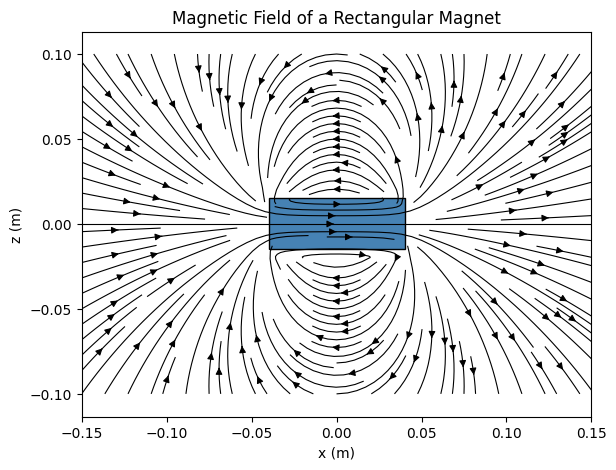

In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from magdiff.components.cuboid import Cuboid
from magdiff.system import MagneticSystem

# Create a rectangular magnet (8cm x 3cm x 3cm) magnetized along x-axis
magnet = Cuboid(
    magnetization=jnp.array([8.0e5, 0.0, 0.0]),  # A/m, pointing in +x direction
    dimension=jnp.array([0.08, 0.03, 0.03]),     # meters
    position=jnp.array([0.0, 0.0, 0.0]),
)

# Create a magnetic system containing our magnet
system = MagneticSystem([magnet])

# Sample the magnetic field on a 2D grid (x-z plane at y=0)
bounds = ((-0.15, 0.15), (-0.01, 0.01), (-0.10, 0.10))  # (x, y, z) bounds in meters
shape = (61, 3, 41)  # grid resolution
volume = system.sample_field_volume(bounds=bounds, shape=shape)

# Extract the middle slice (y=0)
y_idx = shape[1] // 2
xs = np.array(volume.X[:, y_idx, 0])
zs = np.array(volume.Z[0, y_idx, :])
Bx = np.array(volume.B[:, y_idx, :, 0]).T
Bz = np.array(volume.B[:, y_idx, :, 2]).T

# Plot the field
fig, ax = plt.subplots(figsize=(8, 5))
ax.streamplot(xs, zs, Bx, Bz, density=1.5, color="black", linewidth=0.8)
ax.add_patch(plt.Rectangle((-0.04, -0.015), 0.08, 0.03, fc="steelblue", ec="black"))
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_aspect("equal")
ax.set_title("Magnetic Field of a Rectangular Magnet")
plt.show()

In [ ]:
import jax, jax.numpy as jnp
from magdiff.components.dipole import Dipole
from magdiff.system import MagneticSystem
from magdiff.visualize import visualize_field

dip1 = Dipole(name="dipole_1", moment=jnp.array([50.0, 0.0, 0.0]), position=jnp.array([1.0, 0.0, 0.0]),rotation_vector=jnp.zeros(3))
dip2 = Dipole(name="dipole_2", moment=jnp.array([-50.0, 0.0, 0.0]), position=jnp.array([1.0, 1.0, 0.0]),rotation_vector=jnp.zeros(3))
system = MagneticSystem([dip1, dip2], name="sample system")
observer_position = [0.0, 0.0, 0.0]
print(f"B Field at {observer_position} is {system.field_at(observer_position)}")
# B Field at [0.0, 0.0, 0.0] is [ 9.1161164e-06 -2.6516507e-06  0.0000000e+00]
visualize_field(system)


B Field at [0.0, 0.0, 0.0] is [ 9.1161164e-06 -2.6516507e-06  0.0000000e+00]


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'maxdisplayed': 100,
              'sizeref': 0.5,
              'starts': {'x': [0], 'y': [0], 'z': [0]},
              'type': 'streamtube',
              'u': {'bdata': ('yYGVNHHavDS21OI0BbMANWJJCTViSQ' ... 'uAjm47zRQJOSaY2DfwBwk3VulYNg=='),
                    'dtype': 'f4'},
              'v': {'bdata': ('hFjIM65/CDSQVCw0PpZJNNAoWjTQKF' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAA=='),
                    'dtype': 'f4'},
              'w': {'bdata': ('zbtoNE2DXTRIrDk0wAD5M3i+LzN7vi' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAA=='),
                    'dtype': 'f4'},
              'x': {'bdata': ('AACAvwAAgL8AAIC/AACAvwAAgL8AAI' ... '8AAIA/AACAPwAAgD8AAIA/AACAPw=='),
                    'dtype': 'f4'},
              'y': {'bdata': ('AACAvwAAgL8AAIC/AACAvwAAgL8AAI' ... '8AAIA/AACAPwAAgD8AAIA/AACAPw=='),
                    'dtype': 'f4'},
              'z': {'bdata': ('AACAv3IcR7/kOA6/qaqqvjyO471Aju' ... '1AjuM9rKqqPuQ4Dj9yHEc/AACAPw=='),
                    'dtype': 'f4'}},
             {'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                             'rgb(222,235,247)'], [0.25, 'rgb(198,219,239)'],
                             [0.375, 'rgb(158,202,225)'], [0.5,
                             'rgb(107,174,214)'], [0.625, 'rgb(66,146,198)'],
                             [0.75, 'rgb(33,113,181)'], [0.875, 'rgb(8,81,156)'],
                             [1.0, 'rgb(8,48,107)']],
              'showscale': False,
              'sizemode': 'absolute',
              'sizeref': 0.3,
              'type': 'cone',
              'u': [50.0],
              'v': [0.0],
              'w': [0.0],
              'x': [1.0],
              'y': [0.0],
              'z': [0.0]},
             {'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                             'rgb(222,235,247)'], [0.25, 'rgb(198,219,239)'],
                             [0.375, 'rgb(158,202,225)'], [0.5,
                             'rgb(107,174,214)'], [0.625, 'rgb(66,146,198)'],
                             [0.75, 'rgb(33,113,181)'], [0.875, 'rgb(8,81,156)'],
                             [1.0, 'rgb(8,48,107)']],
              'showscale': False,
              'sizemode': 'absolute',
              'sizeref': 0.3,
              'type': 'cone',
              'u': [-50.0],
              'v': [0.0],
              'w': [0.0],
              'x': [1.0],
              'y': [1.0],
              'z': [0.0]}],
    'layout': {'scene': {'xaxis': {'title': {'text': 'X'}},
                         'yaxis': {'title': {'text': 'Y'}},
                         'zaxis': {'title': {'text': 'Z'}}},
               'template': '...',
               'title': {'text': 'Magnetic Field Visualization'}}
})